# Project 2: Reproducibility in Natural Language Processing



## Part 4: Word Frequency Analysis in State of the Union Addresses

This section examines the word frequency over time for State of the Union. The central question we are answering is "does the frequency of certain words change over time"? The first section, completed by Owen, identifies common words from the 21st centery and the second section, completed by Allison, will all analyse these words overtime. 

### Read Data

In [4]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-dark')

In [5]:
sou = pd.read_csv("data/SOTU.csv")

### Processing Speeches with SpaCy

In [6]:
import spacy
from tqdm import tqdm
from collections import Counter

nlp = spacy.load("en_core_web_sm")

### Part One: Common Words

#### Common Words per Year Function

In [7]:
def get_most_common_words(df, year, n=25):
    """
    Processes the SOTU speech for a given year and returns
    the most common non-stopword/punctuation lemmas.
    """

    # Step 1: Subset df
    subset_df = df[df["Year"]==int(year)]

    # Step 2: Process the text with spaCy
    speeches = []
    for speech in subset_df["Text"]:
        speech_tokens = nlp(speech)
        speeches.append(speech_tokens)
    
    # Step 3: Get lemmas
    lemmas = []
    for speech in speeches:
        for token in speech:
            if (token.is_stop==False) & (token.is_punct==False) & (token.is_space==False) & (len(token)>2):
                lemma = token.lemma_
                lemmas.append(lemma.lower())
    top_lemmas = Counter(lemmas).most_common(n)
    
    return top_lemmas

In [8]:
# Subset to 2000 onwards
sou2k = sou[sou["Year"] > 1999]

# Top 10 words saved in dictionary for each year
dfs = {}
for year in sou2k["Year"]:
    words = get_most_common_words(sou2k, year, n=10)
    dfs[year] = pd.DataFrame(words)
    dfs[year].columns = ["Word", "Count"]

### Exploratory Data Analysis of Word Frequencies Over Time

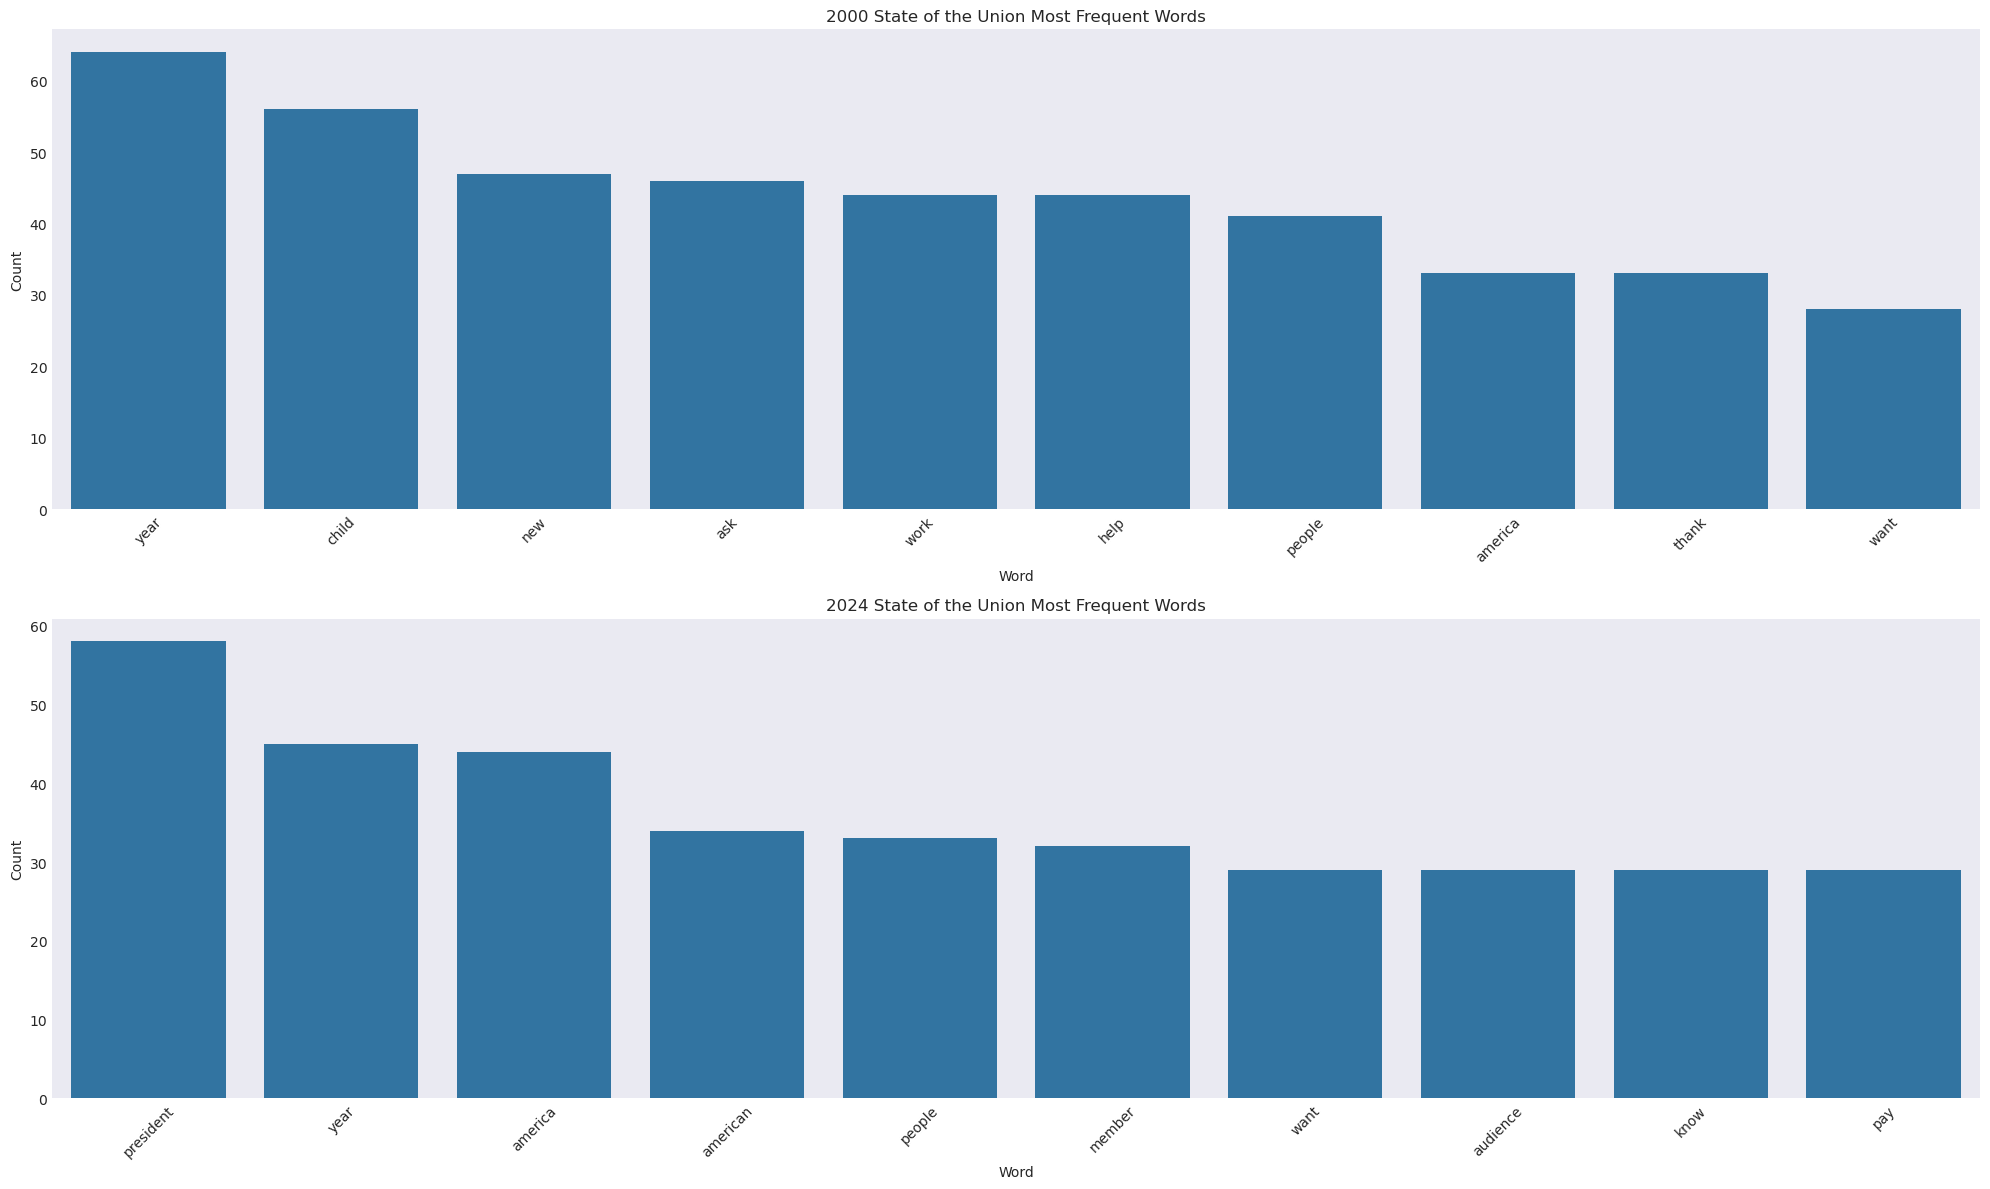

In [9]:
# Bar plots for 2000 and 2024
fig, axes = plt.subplots(2, 1, figsize=(20, 12))

# 2000
sns.barplot(data=dfs[2000], x="Word", y="Count", ax=axes[0])
axes[0].set_title("2000 State of the Union Most Frequent Words")
axes[0].tick_params(axis="x", rotation=45)

# 2024
sns.barplot(data=dfs[2024], x="Word", y="Count", ax=axes[1])
axes[1].set_title("2024 State of the Union Most Frequent Words")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
# plt.savefig(outputs_dir / "2000_2024_sou_frequent_words.png", dpi=300, bbox_inches="tight")
plt.show();

### Commentary

Absense of "president" stands out in 2000: may be worth investigating further. Pay and America also seem like viable candidates for analysis.

The 2000 and 2024 speeches share high-frequency words such as “year”, “america”, and “people”, reflecting persistent themes of national identity and citizens.
However, the prominence of words like “president” and “pay” in 2024 suggests a stronger focus on presidential authority and economic concerns in more recent speeches.

## Part 2: Frequency of Selected Words Over the Entire SOU History (1790–2024)

Based on the analysis from Owen above and my knowlwdge of American hisotry I have selected the words ["america", "president", "war", "economy", "freedom", "pay"] for analysis. I suspect that "president" and "pay" will be common in more modern times, as preseidntial powers have genrally incerased overtime, while the others will seee more consistant usage. 

In [14]:
tracked_words = ["america", "president", "war", "economy", "freedom", "pay"]

In [15]:
def count_words_year(df, year, words):
    subset_df = df[df["Year"] == int(year)]

    docs = [nlp(text) for text in subset_df["Text"]]

    lemmas = []
    for doc in docs:
        for token in doc:
            if (
                not token.is_stop
                and not token.is_punct
                and not token.is_space
                and len(token) > 2
            ):
                lemmas.append(token.lemma_.lower())

    lemma_counts = Counter(lemmas)

    result = {"Word": [], "Count": []}
    for w in words:
        result["Word"].append(w)
        result["Count"].append(lemma_counts[w])

    return pd.DataFrame(result)


In [16]:
years = sorted(sou["Year"].unique())

trend_data = {"Year": years}
for w in tracked_words:
    trend_data[w] = []

for year in years:
    df_counts = count_words_year(sou, year, tracked_words)
    for w in tracked_words:
        count = df_counts.loc[df_counts["Word"] == w, "Count"].values[0]
        trend_data[w].append(count)

trend_df = pd.DataFrame(trend_data)
trend_df.head()


,Year,america,president,war,economy,freedom,pay
0,1790.0,0,0,4,4,0,0
1,1791.0,0,0,2,0,0,2
2,1792.0,0,0,4,0,0,0
3,1793.0,0,0,4,1,1,1
4,1794.0,0,0,1,1,0,0


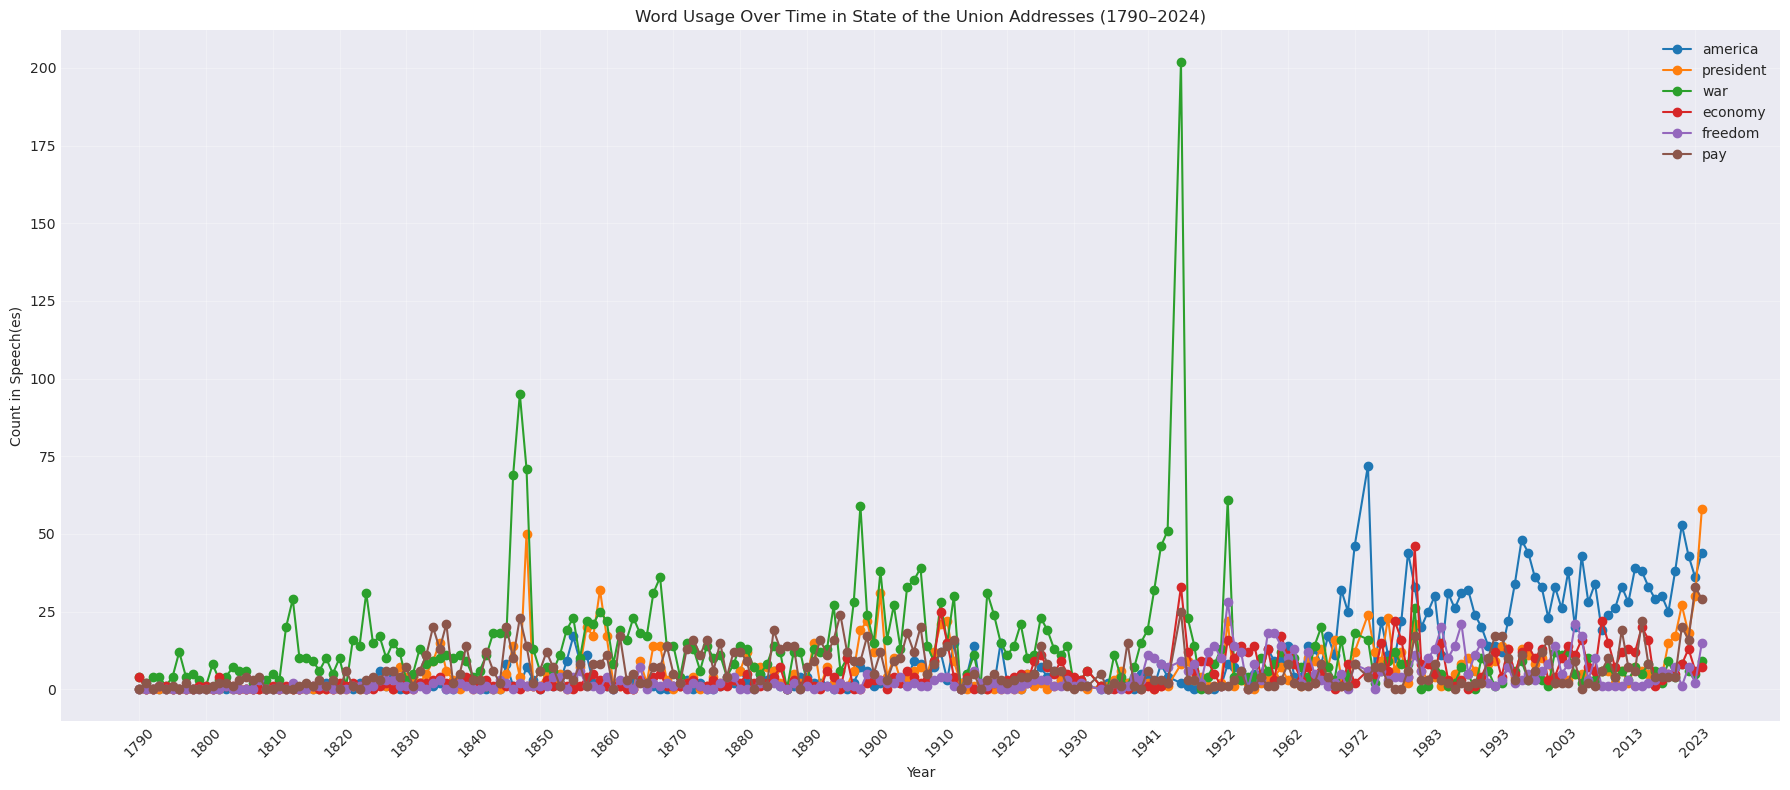

In [17]:
plt.figure(figsize=(18, 8))

for w in tracked_words:
    plt.plot(trend_df["Year"], trend_df[w], marker="o", linewidth=1.5, label=w)

plt.title("Word Usage Over Time in State of the Union Addresses (1790–2024)")
plt.xlabel("Year")
plt.ylabel("Count in Speech(es)")
plt.xticks(trend_df["Year"][::10], rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(16, 8))

for w in words:
    plt.plot(trend_df["Year"], trend_df[w], marker="o", label=w)

plt.title("Word Usage Frequency Over Time (2000–2024)")
plt.xlabel("Year")
plt.ylabel("Count")
plt.xticks(years, rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Commentary & Analysis

The word with the highest peaks is "war" used mainly during times in of war and peaking in 1944-1945 during World War Two. Since the mid Sixties, "america" is the most consistant the most popular word of the 6. The word "pay" has also been fairly consistant since the early 20th centry and not a recent trend as initally hypothesized, peaking in around 1953. "president" has seen a exponetial increase in reent yeasts as predicted though there have been multiple peaks thoughout hisotry include two in the decades preceeding the Civil War. "economy" and "freedom" have also stayed fairly consistant, with smaller shorter peaks likely due to the semantic preferences of certain presidents. 